Imports and Device Configuration


In [1]:


import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import sqrtm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Environment Setup Complete.")
print(f"Currently using device: {device}")

if device.type == 'cuda':
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

Environment Setup Complete.
Currently using device: cpu


Data Pipelines and Loaders


100%|██████████| 9.91M/9.91M [00:00<00:00, 58.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.75MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 15.1MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.46MB/s]


Training Data: 60000 images
Testing Data: 10000 images


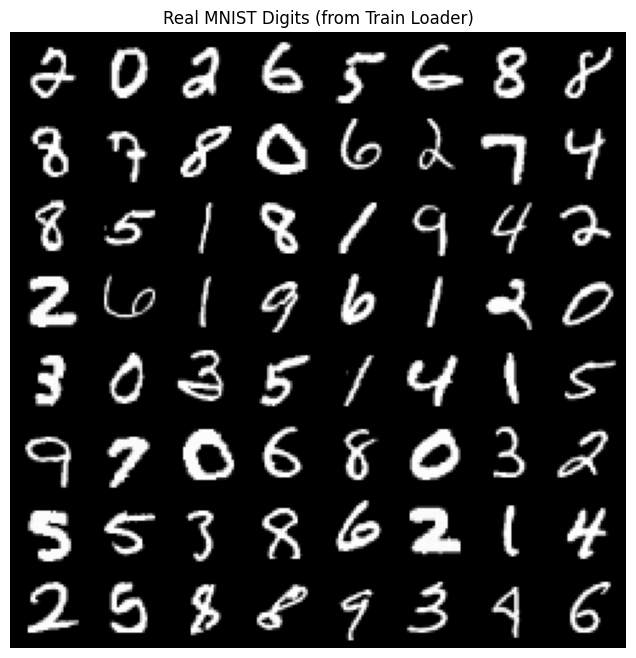

In [2]:


BATCH_SIZE = 128

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

print("Downloading MNIST Dataset...")
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)

train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

print(f"Training Data: {len(train_dataset)} images")
print(f"Testing Data: {len(test_dataset)} images")


def show_images(images, title=""):
    """
    Un-normalizes the images from [-1, 1] back to [0, 1]
    and plots them in a grid.
    """
    images = images.detach().cpu()
    images = images / 2 + 0.5

    grid = make_grid(images[:64], nrow=8).permute(1, 2, 0)
    plt.figure(figsize=(8, 8))
    plt.imshow(grid.numpy())
    plt.title(title)
    plt.axis('off')
    plt.show()

data_iter = iter(train_loader)
images, labels = next(data_iter)
show_images(images, title="Real MNIST Digits (from Train Loader)")

 The "Judge" (Classifier Architecture)


In [3]:


class MNISTJudge(nn.Module):
    def __init__(self):
        super(MNISTJudge, self).__init__()


        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )


        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):

        x = self.conv_layers(x)


        x = x.view(x.size(0), -1)


        features = F.relu(self.fc1(x))

        logits = self.fc2(features)

        return logits, features

judge_model = MNISTJudge().to(device)

dummy_input = torch.randn(BATCH_SIZE, 1, 28, 28).to(device)
test_logits, test_features = judge_model(dummy_input)

print(f"Judge initialized on {device}.")
print(f"Output Logits shape: {test_logits.shape} (Expected: {BATCH_SIZE}, 10)")
print(f"Output Features shape: {test_features.shape} (Expected: {BATCH_SIZE}, 128)")

Judge initialized on cpu.
Output Logits shape: torch.Size([128, 10]) (Expected: 128, 10)
Output Features shape: torch.Size([128, 128]) (Expected: 128, 128)


Training the Judge


In [4]:


criterion_judge = nn.CrossEntropyLoss()
optimizer_judge = optim.Adam(judge_model.parameters(), lr=0.001)

EPOCHS_JUDGE = 5

print("Starting training for the Judge (Classifier)...")

for epoch in range(EPOCHS_JUDGE):
    judge_model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for i, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        optimizer_judge.zero_grad()

        logits, _ = judge_model(images)
        loss = criterion_judge(logits, labels)

        loss.backward()
        optimizer_judge.step()

        running_loss += loss.item()

        _, predicted = torch.max(logits.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total

    print(f"Epoch [{epoch+1}/{EPOCHS_JUDGE}] | Loss: {epoch_loss:.4f} | Training Accuracy: {epoch_acc:.2f}%")

judge_model.eval()
test_correct = 0
test_total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        logits, _ = judge_model(images)
        _, predicted = torch.max(logits.data, 1)
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

test_acc = 100 * test_correct / test_total
print(f"--> Final Test Accuracy on Unseen Data: {test_acc:.2f}%")

for param in judge_model.parameters():
    param.requires_grad = False

Starting training for the Judge (Classifier)...
Epoch [1/5] | Loss: 0.2894 | Training Accuracy: 91.59%
Epoch [2/5] | Loss: 0.0675 | Training Accuracy: 97.89%
Epoch [3/5] | Loss: 0.0494 | Training Accuracy: 98.48%
Epoch [4/5] | Loss: 0.0385 | Training Accuracy: 98.81%
Epoch [5/5] | Loss: 0.0308 | Training Accuracy: 99.01%
--> Final Test Accuracy on Unseen Data: 98.55%


 Feature Extractor Prep (Helper)


In [5]:


def extract_features_and_probs(images, model):

    model.eval()

    with torch.no_grad():
        logits, features = model(images)

        probs = F.softmax(logits, dim=1)

    return probs, features

sample_images, _ = next(iter(test_loader))
sample_images = sample_images.to(device)

sample_probs, sample_features = extract_features_and_probs(sample_images, judge_model)

print("Feature Extractor Ready!")
print(f"Input Images Shape: {sample_images.shape}")
print(f"Extracted Probabilities Shape: {sample_probs.shape} (Expected: BATCH_SIZE, 10)")
print(f"Extracted Features Shape: {sample_features.shape} (Expected: BATCH_SIZE, 128)")

first_image_probs = sample_probs[0]
predicted_class = torch.argmax(first_image_probs).item()
confidence = first_image_probs[predicted_class].item() * 100

print(f"\nSanity Check on First Image:")
print(f"Judge predicts this is a '{predicted_class}' with {confidence:.2f}% confidence.")

Feature Extractor Ready!
Input Images Shape: torch.Size([128, 1, 28, 28])
Extracted Probabilities Shape: torch.Size([128, 10]) (Expected: BATCH_SIZE, 10)
Extracted Features Shape: torch.Size([128, 128]) (Expected: BATCH_SIZE, 128)

Sanity Check on First Image:
Judge predicts this is a '7' with 100.00% confidence.


 VAE Architecture


In [6]:
LATENT_DIM = 20

class VAE(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super(VAE, self).__init__()


        self.fc1 = nn.Linear(784, 400)


        self.fc_mu = nn.Linear(400, latent_dim)
        self.fc_logvar = nn.Linear(400, latent_dim)

        self.fc3 = nn.Linear(latent_dim, 400)
        self.fc4 = nn.Linear(400, 784)

    def encode(self, x):
        h1 = F.relu(self.fc1(x))
        mu = self.fc_mu(h1)
        logvar = self.fc_logvar(h1)
        return mu, logvar

    def reparameterize(self, mu, logvar):

        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h3 = F.relu(self.fc3(z))


        reconstruction = torch.tanh(self.fc4(h3))
        return reconstruction

    def forward(self, x):
        x_flat = x.view(-1, 784)

        mu, logvar = self.encode(x_flat)

        z = self.reparameterize(mu, logvar)

        x_reconstructed_flat = self.decode(z)

        x_reconstructed = x_reconstructed_flat.view(-1, 1, 28, 28)

        return x_reconstructed, mu, logvar

vae_model = VAE(latent_dim=LATENT_DIM).to(device)
print(f"VAE Model initialized on {device}.")

VAE Model initialized on cpu.


VAE Loss Function and Optimizer

In [7]:


def vae_loss_function(recon_x, x, mu, logvar):


    recon_loss = F.mse_loss(recon_x, x, reduction='sum')


    kld_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    total_loss = recon_loss + kld_loss


    batch_size = x.size(0)

    return total_loss / batch_size, recon_loss / batch_size, kld_loss / batch_size



optimizer_vae = optim.Adam(vae_model.parameters(), lr=1e-3)

print("VAE Loss Function and Optimizer configured.")

VAE Loss Function and Optimizer configured.


 VAE Training Loop


Starting VAE Training...
Epoch [1/50] | Total Loss: 122.4815 | Recon Loss: 100.7249 | KL Loss: 21.7566
Epoch [2/50] | Total Loss: 82.5043 | Recon Loss: 56.0422 | KL Loss: 26.4620
Epoch [3/50] | Total Loss: 77.1996 | Recon Loss: 49.9533 | KL Loss: 27.2463
Epoch [4/50] | Total Loss: 74.5234 | Recon Loss: 47.0473 | KL Loss: 27.4761
Epoch [5/50] | Total Loss: 72.8322 | Recon Loss: 45.1737 | KL Loss: 27.6584
Epoch [6/50] | Total Loss: 71.7235 | Recon Loss: 43.9368 | KL Loss: 27.7868
Epoch [7/50] | Total Loss: 70.8683 | Recon Loss: 43.0163 | KL Loss: 27.8521
Epoch [8/50] | Total Loss: 70.1434 | Recon Loss: 42.2004 | KL Loss: 27.9430
Epoch [9/50] | Total Loss: 69.5245 | Recon Loss: 41.5450 | KL Loss: 27.9794
Epoch [10/50] | Total Loss: 69.0587 | Recon Loss: 41.0196 | KL Loss: 28.0391
Epoch [11/50] | Total Loss: 68.6779 | Recon Loss: 40.5834 | KL Loss: 28.0945
Epoch [12/50] | Total Loss: 68.3380 | Recon Loss: 40.2027 | KL Loss: 28.1353
Epoch [13/50] | Total Loss: 67.9995 | Recon Loss: 39.8565 

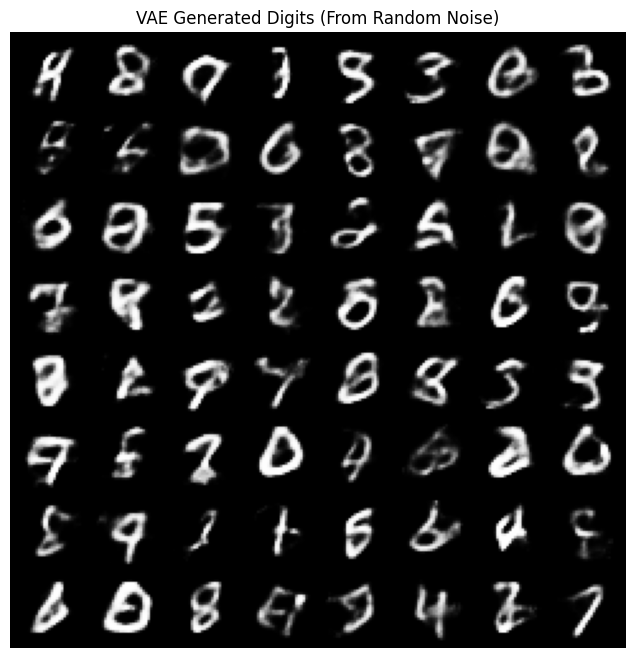

In [8]:

EPOCHS_VAE = 50

vae_train_losses = []
vae_recon_losses = []
vae_kl_losses = []

print("Starting VAE Training...")

for epoch in range(EPOCHS_VAE):
    vae_model.train()

    train_loss = 0.0
    train_recon = 0.0
    train_kl = 0.0

    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)

        optimizer_vae.zero_grad()

        recon_batch, mu, logvar = vae_model(data)

        loss, recon, kl = vae_loss_function(recon_batch, data, mu, logvar)

        loss.backward()
        optimizer_vae.step()

        train_loss += loss.item()
        train_recon += recon.item()
        train_kl += kl.item()

    avg_loss = train_loss / len(train_loader)
    avg_recon = train_recon / len(train_loader)
    avg_kl = train_kl / len(train_loader)

    vae_train_losses.append(avg_loss)
    vae_recon_losses.append(avg_recon)
    vae_kl_losses.append(avg_kl)

    print(f"Epoch [{epoch+1}/{EPOCHS_VAE}] | Total Loss: {avg_loss:.4f} | Recon Loss: {avg_recon:.4f} | KL Loss: {avg_kl:.4f}")

print("VAE Training Complete!")


vae_model.eval()
with torch.no_grad():

    sample_noise = torch.randn(64, LATENT_DIM).to(device)


    generated_flat = vae_model.decode(sample_noise)

    generated_images = generated_flat.view(-1, 1, 28, 28)

    show_images(generated_images, title="VAE Generated Digits (From Random Noise)")

GAN Architecture

In [9]:

GAN_LATENT_DIM = 20

class Generator(nn.Module):
    def __init__(self, latent_dim=GAN_LATENT_DIM):
        super(Generator, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(256, 512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(512, 784),
            nn.Tanh()
        )

    def forward(self, z):
        img_flat = self.model(z)

        img = img_flat.view(-1, 1, 28, 28)
        return img

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, img):
        img_flat = img.view(img.size(0), -1)

        validity = self.model(img_flat)
        return validity

generator = Generator(latent_dim=GAN_LATENT_DIM).to(device)
discriminator = Discriminator().to(device)

print(f"Generator and Discriminator initialized on {device}.")

Generator and Discriminator initialized on cpu.


GAN Loss and Optimizers

In [10]:

adversarial_loss = nn.BCELoss()


lr = 0.0002
b1 = 0.5
b2 = 0.999

optimizer_G = optim.Adam(generator.parameters(), lr=lr, betas=(b1, b2))
optimizer_D = optim.Adam(discriminator.parameters(), lr=lr, betas=(b1, b2))

print("GAN Loss Function and Optimizers configured.")

GAN Loss Function and Optimizers configured.


GAN Training Loop

Starting GAN Training...
Epoch [1/50] | D Loss: 0.4884 | G Loss: 1.3406
Epoch [2/50] | D Loss: 0.4160 | G Loss: 1.8334
Epoch [3/50] | D Loss: 0.3714 | G Loss: 2.1389
Epoch [4/50] | D Loss: 0.3298 | G Loss: 2.4293
Epoch [5/50] | D Loss: 0.3612 | G Loss: 2.3440
Epoch [6/50] | D Loss: 0.3512 | G Loss: 2.3361
Epoch [7/50] | D Loss: 0.3091 | G Loss: 2.5682
Epoch [8/50] | D Loss: 0.3277 | G Loss: 2.4193
Epoch [9/50] | D Loss: 0.3017 | G Loss: 2.7049
Epoch [10/50] | D Loss: 0.2971 | G Loss: 2.6933
Epoch [11/50] | D Loss: 0.3322 | G Loss: 2.4146
Epoch [12/50] | D Loss: 0.3325 | G Loss: 2.3505
Epoch [13/50] | D Loss: 0.3667 | G Loss: 2.1479
Epoch [14/50] | D Loss: 0.3888 | G Loss: 2.0088
Epoch [15/50] | D Loss: 0.4380 | G Loss: 1.7652
Epoch [16/50] | D Loss: 0.4701 | G Loss: 1.5910
Epoch [17/50] | D Loss: 0.4758 | G Loss: 1.5248
Epoch [18/50] | D Loss: 0.4982 | G Loss: 1.4312
Epoch [19/50] | D Loss: 0.5110 | G Loss: 1.3732
Epoch [20/50] | D Loss: 0.5187 | G Loss: 1.3325
Epoch [21/50] | D Loss: 

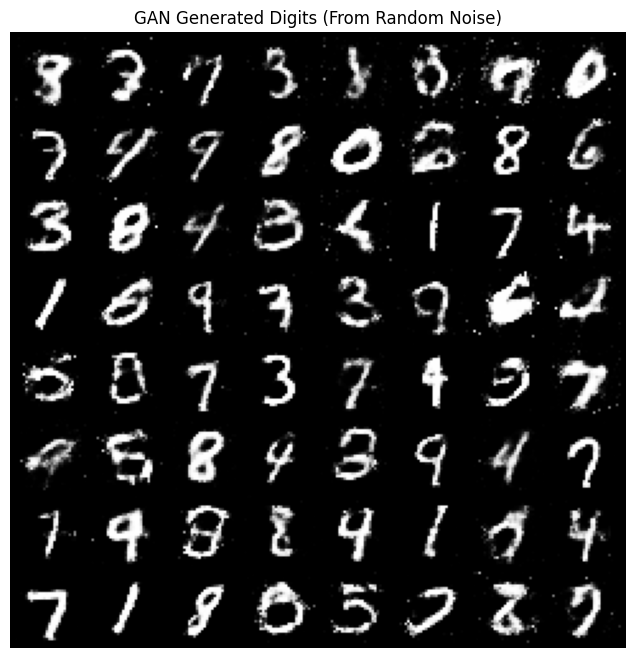

In [11]:


EPOCHS_GAN = 50

gan_g_losses = []
gan_d_losses = []

print("Starting GAN Training...")

for epoch in range(EPOCHS_GAN):
    generator.train()
    discriminator.train()

    g_loss_epoch = 0.0
    d_loss_epoch = 0.0

    for i, (imgs, _) in enumerate(train_loader):

        real_imgs = imgs.to(device)
        batch_size = real_imgs.size(0)

        valid_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        optimizer_D.zero_grad()

        real_loss = adversarial_loss(discriminator(real_imgs), valid_labels)

        z = torch.randn(batch_size, GAN_LATENT_DIM).to(device)
        fake_imgs = generator(z)

        fake_loss = adversarial_loss(discriminator(fake_imgs.detach()), fake_labels)

        d_loss = (real_loss + fake_loss) / 2
        d_loss.backward()
        optimizer_D.step()

        optimizer_G.zero_grad()

        g_loss = adversarial_loss(discriminator(fake_imgs), valid_labels)

        g_loss.backward()
        optimizer_G.step()

        g_loss_epoch += g_loss.item()
        d_loss_epoch += d_loss.item()

    avg_g_loss = g_loss_epoch / len(train_loader)
    avg_d_loss = d_loss_epoch / len(train_loader)

    gan_g_losses.append(avg_g_loss)
    gan_d_losses.append(avg_d_loss)

    print(f"Epoch [{epoch+1}/{EPOCHS_GAN}] | D Loss: {avg_d_loss:.4f} | G Loss: {avg_g_loss:.4f}")

print("GAN Training Complete!")

generator.eval()
with torch.no_grad():
    sample_noise = torch.randn(64, GAN_LATENT_DIM).to(device)

    generated_images = generator(sample_noise)

    show_images(generated_images, title="GAN Generated Digits (From Random Noise)")

Visuals & Interpolation

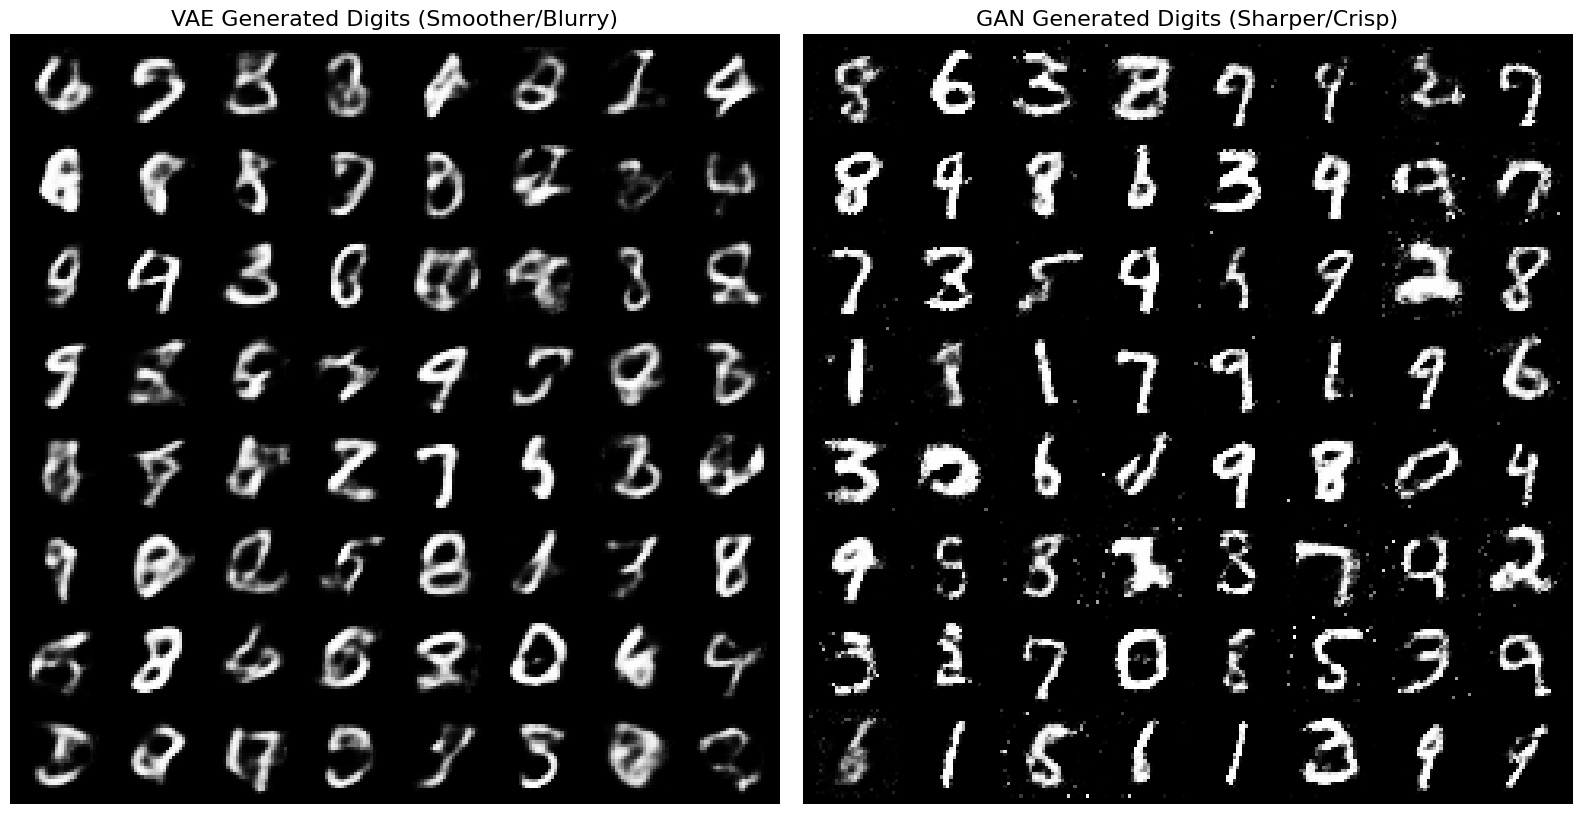

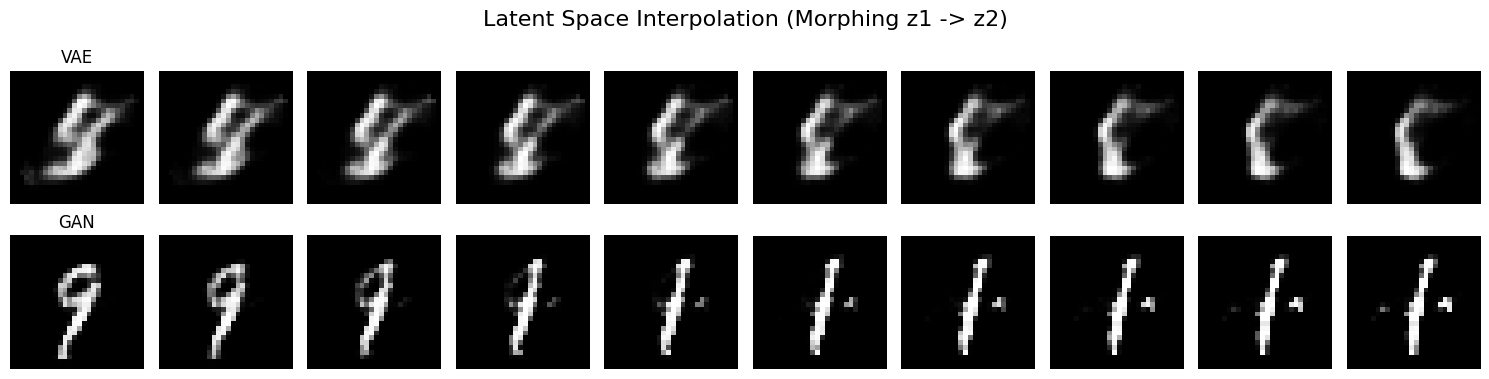

In [12]:

vae_model.eval()
generator.eval()

with torch.no_grad():

    shared_noise = torch.randn(64, 20).to(device)


    vae_generated_flat = vae_model.decode(shared_noise)
    vae_imgs = vae_generated_flat.view(-1, 1, 28, 28).cpu()

    gan_imgs = generator(shared_noise).cpu()


    vae_imgs = vae_imgs / 2 + 0.5
    gan_imgs = gan_imgs / 2 + 0.5


    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    vae_grid = make_grid(vae_imgs, nrow=8).permute(1, 2, 0).numpy()
    axes[0].imshow(vae_grid)
    axes[0].set_title("VAE Generated Digits (Smoother/Blurry)", fontsize=16)
    axes[0].axis('off')

    gan_grid = make_grid(gan_imgs, nrow=8).permute(1, 2, 0).numpy()
    axes[1].imshow(gan_grid)
    axes[1].set_title("GAN Generated Digits (Sharper/Crisp)", fontsize=16)
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()


num_steps = 10


with torch.no_grad():

    z1 = torch.randn(1, 20).to(device)
    z2 = torch.randn(1, 20).to(device)


    alphas = torch.linspace(0, 1, steps=num_steps).to(device)


    z_interp = z1 * (1 - alphas.unsqueeze(1)) + z2 * alphas.unsqueeze(1)

    vae_interp_flat = vae_model.decode(z_interp)
    vae_interp_imgs = vae_interp_flat.view(-1, 1, 28, 28).cpu()

    gan_interp_imgs = generator(z_interp).cpu()

    vae_interp_imgs = vae_interp_imgs / 2 + 0.5
    gan_interp_imgs = gan_interp_imgs / 2 + 0.5

    fig, axes = plt.subplots(2, num_steps, figsize=(15, 4))
    fig.suptitle("Latent Space Interpolation (Morphing z1 -> z2)", fontsize=16)

    for i in range(num_steps):
        axes[0, i].imshow(vae_interp_imgs[i].squeeze(), cmap='gray')
        axes[0, i].axis('off')
        if i == 0: axes[0, i].set_title("VAE")

        axes[1, i].imshow(gan_interp_imgs[i].squeeze(), cmap='gray')
        axes[1, i].axis('off')
        if i == 0: axes[1, i].set_title("GAN")

    plt.tight_layout()
    plt.show()

Training Stability (Loss Curves)

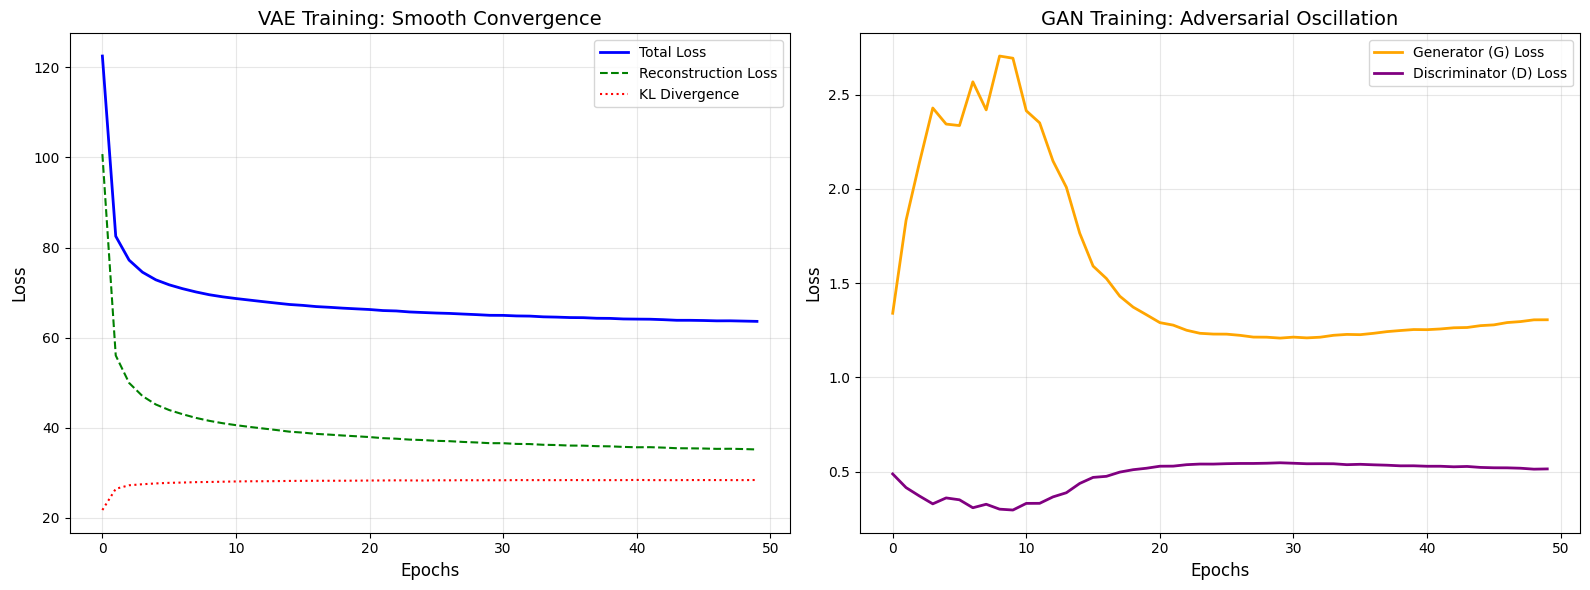

In [13]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(vae_train_losses, label='Total Loss', color='blue', linewidth=2)
axes[0].plot(vae_recon_losses, label='Reconstruction Loss', color='green', linestyle='--')
axes[0].plot(vae_kl_losses, label='KL Divergence', color='red', linestyle=':')

axes[0].set_title("VAE Training: Smooth Convergence", fontsize=14)
axes[0].set_xlabel("Epochs", fontsize=12)
axes[0].set_ylabel("Loss", fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)


axes[1].plot(gan_g_losses, label='Generator (G) Loss', color='orange', linewidth=2)
axes[1].plot(gan_d_losses, label='Discriminator (D) Loss', color='purple', linewidth=2)

axes[1].set_title("GAN Training: Adversarial Oscillation", fontsize=14)
axes[1].set_xlabel("Epochs", fontsize=12)
axes[1].set_ylabel("Loss", fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Confidence Score

In [14]:

NUM_EVAL_IMAGES = 5000

vae_model.eval()
generator.eval()
judge_model.eval()

with torch.no_grad():
    eval_noise = torch.randn(NUM_EVAL_IMAGES, 20).to(device)

    vae_generated_flat = vae_model.decode(eval_noise)
    vae_eval_imgs = vae_generated_flat.view(-1, 1, 28, 28)

    gan_eval_imgs = generator(eval_noise)

    vae_probs, _ = extract_features_and_probs(vae_eval_imgs, judge_model)
    gan_probs, _ = extract_features_and_probs(gan_eval_imgs, judge_model)


    vae_confidences, vae_predictions = torch.max(vae_probs, dim=1)
    gan_confidences, gan_predictions = torch.max(gan_probs, dim=1)

    vae_avg_confidence = vae_confidences.mean().item() * 100
    gan_avg_confidence = gan_confidences.mean().item() * 100

print("--- Quantitative Evaluation: Confidence ---")
print(f"VAE Average Confidence: {vae_avg_confidence:.2f}%")
print(f"GAN Average Confidence: {gan_avg_confidence:.2f}%")

--- Quantitative Evaluation: Confidence ---
VAE Average Confidence: 78.67%
GAN Average Confidence: 90.25%


Diversity Score (Mode Collapse Check)

--- Quantitative Evaluation: Diversity (Entropy) ---
Ideal Uniform Entropy: 2.3026
VAE Diversity Entropy: 2.2407
GAN Diversity Entropy: 2.2056



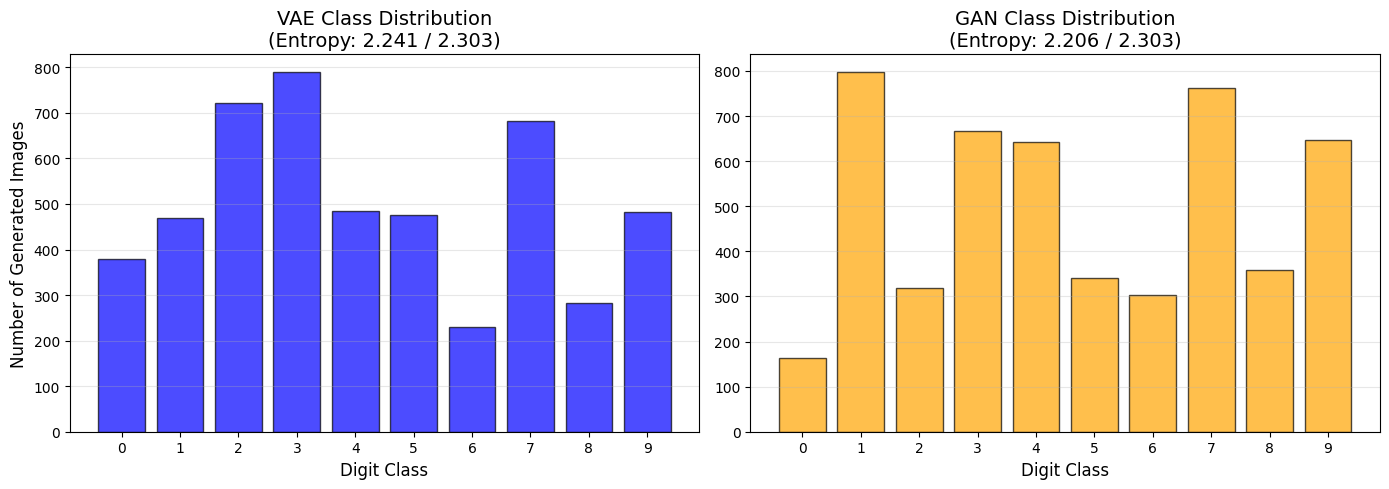

In [15]:


import numpy as np
from collections import Counter

def calculate_diversity(predictions, num_classes=10):

    counts = Counter(predictions.cpu().numpy())

    distribution = [counts.get(i, 0) for i in range(num_classes)]

    probs = np.array(distribution) / sum(distribution)


    entropy = -np.sum(probs * np.log(probs + 1e-9))

    return distribution, entropy

vae_dist, vae_entropy = calculate_diversity(vae_predictions)
gan_dist, gan_entropy = calculate_diversity(gan_predictions)

max_entropy = np.log(10)

print("--- Quantitative Evaluation: Diversity (Entropy) ---")
print(f"Ideal Uniform Entropy: {max_entropy:.4f}")
print(f"VAE Diversity Entropy: {vae_entropy:.4f}")
print(f"GAN Diversity Entropy: {gan_entropy:.4f}\n")


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
classes = np.arange(10)

axes[0].bar(classes, vae_dist, color='blue', alpha=0.7, edgecolor='black')
axes[0].set_title(f"VAE Class Distribution\n(Entropy: {vae_entropy:.3f} / {max_entropy:.3f})", fontsize=14)
axes[0].set_xticks(classes)
axes[0].set_xlabel("Digit Class", fontsize=12)
axes[0].set_ylabel("Number of Generated Images", fontsize=12)
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(classes, gan_dist, color='orange', alpha=0.7, edgecolor='black')
axes[1].set_title(f"GAN Class Distribution\n(Entropy: {gan_entropy:.3f} / {max_entropy:.3f})", fontsize=14)
axes[1].set_xticks(classes)
axes[1].set_xlabel("Digit Class", fontsize=12)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Custom FID Calculation

In [16]:
def calculate_frechet_distance(features_real, features_gen):
    """
    Calculates the Fréchet distance between two sets of feature vectors.
    """
    act1 = features_real.cpu().numpy()
    act2 = features_gen.cpu().numpy()

    mu1, sigma1 = act1.mean(axis=0), np.cov(act1, rowvar=False)
    mu2, sigma2 = act2.mean(axis=0), np.cov(act2, rowvar=False)

    ssdiff = np.sum((mu1 - mu2)**2.0)
    covmean = sqrtm(sigma1.dot(sigma2))

    if np.iscomplexobj(covmean):
        covmean = covmean.real

    fid = ssdiff + np.trace(sigma1 + sigma2 - 2.0 * covmean)
    return fid

print("Gathering features for FID calculation (This may take a moment)...")

real_features_list = []
num_batches_to_collect = 40 # 40 batches * 128 batch_size = 5120 images

# 1. Collect a large sample of real features for a stable covariance matrix
with torch.no_grad():
    for i, (imgs, _) in enumerate(test_loader):
        if i >= num_batches_to_collect:
            break
        imgs = imgs.to(device)
        _, feats = extract_features_and_probs(imgs, judge_model)
        real_features_list.append(feats)

real_features_all = torch.cat(real_features_list, dim=0)
num_fid_samples = real_features_all.size(0)

print(f"Collected {num_fid_samples} real image features.")

# 2. Generate an equal amount of fake images and extract features
with torch.no_grad():
    # VAE Generation
    vae_fid_noise = torch.randn(num_fid_samples, LATENT_DIM).to(device)
    vae_gen_flat = vae_model.decode(vae_fid_noise)
    vae_gen_imgs = vae_gen_flat.view(-1, 1, 28, 28)
    _, vae_features_all = extract_features_and_probs(vae_gen_imgs, judge_model)

    # GAN Generation
    gan_fid_noise = torch.randn(num_fid_samples, GAN_LATENT_DIM).to(device)
    gan_gen_imgs = generator(gan_fid_noise)
    _, gan_features_all = extract_features_and_probs(gan_gen_imgs, judge_model)

# 3. Calculate FID
vae_fid = calculate_frechet_distance(real_features_all, vae_features_all)
gan_fid = calculate_frechet_distance(real_features_all, gan_features_all)

print("\n--- Quantitative Evaluation: Custom FID Score ---")
print("(Lower is better. 0.0 means identical to real data distribution)")
print(f"VAE FID Score: {vae_fid:.2f}")
print(f"GAN FID Score: {gan_fid:.2f}")

Gathering features for FID calculation (This may take a moment)...
Collected 5120 real image features.

--- Quantitative Evaluation: Custom FID Score ---
(Lower is better. 0.0 means identical to real data distribution)
VAE FID Score: 162.69
GAN FID Score: 64.61


/tmp/ipython-input-3733179802.py:12: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  covmean = sqrtm(sigma1.dot(sigma2))
